# Section 1. Introduction

# Section 2. Description of the Dataset

The data is comprised of patient records from Jamalpur Medical College Hospital in Bangladesh from January 2024 to January 2025. The dataset was obtained from Kaggle by researcher Ahmed Zaki and is structured as a single file in the widely-used CSV (Comma-Separated Values) format. Each row in the dataset represents a patient with each column corresponding to a different lifestyle attribute. 

Total Records:	1,529 patient samples

Total Features:	22 clinical & lifestyle attributes

- **Sex** : biological sex of the patient; *male* or *female*

- **Age** : age of the patient (years)

- **Weight (kg)** : body weight of the patient measured in kilograms

- **Height (cm)** : height of the patient measured in centimeters

- **BMI (Body Mass Index)** : body fat indicator calculated from weight and height (kg/m²)

- **Abdominal Circumference (cm)** : measurement of waist size used to assess central obesity

- **Waist-to-Height Ratio** : ratio of waist circumference to height used to evaluate cardiometabolic risk

- **Systolic BP (mmHg)** : arterial blood pressure during heart contraction

- **Diastolic BP (mmHg)** : arterial blood pressure during heart relaxation

- **Blood Pressure Category** : classification of blood pressure level (e.g., normal, elevated, hypertensive)

- **Total Cholesterol (mg/dL)** : total amount of cholesterol present in the blood

- **HDL (mg/dL)** : high-density lipoprotein cholesterol, often referred to as *good cholesterol*

- **Estimated LDL (mg/dL)** : low-density lipoprotein cholesterol, often referred to as *bad cholesterol*

- **Fasting Blood Sugar (mg/dL)** : blood glucose level measured after fasting

- **Smoking Status** : indicates whether the patient is a smoker or non-smoker

- **Physical Activity Level** : level of regular physical activity performed by the patient

- **Diabetes Status** : indicates whether the patient has diabetes

- **Family History of CVD** : indicates whether immediate family members have cardiovascular disease

- **CVD Risk Score** : numerical score estimating the probability of cardiovascular disease based on health indicators

- **CVD Risk Level** : categorical classification of cardiovascular disease risk; *Low*, *Intermediary*, or *High*

# Section 3. List of Requirements

In [1]:
# Data Manipulation and Visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Statistical Tests
from scipy.stats import f_oneway, chi2_contingency

# Model Training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter

# Section 4. Data Preparation

#### Reading the Data

In [2]:
df = pd.read_csv('CVD.csv')
df.head(10)

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY
5,F,58.0,117.9,1.87,33.7,81.4,142/90,156.0,67.0,82.0,...,Moderate,Y,187.0,0.435,142.0,90.0,Hypertension Stage 2,59.0,16.96,HIGH
6,M,33.0,117.9,1.82,35.6,74.8,96/63,184.0,66.0,87.0,...,Low,N,182.0,0.411,96.0,63.0,Normal,88.0,17.60,INTERMEDIARY
7,M,55.0,100.1,1.74,33.1,96.6,115/73,287.0,40.0,96.0,...,Moderate,N,174.0,0.555,115.0,73.0,Normal,217.0,18.11,HIGH
8,F,37.0,110.1,1.86,31.8,92.4,107/95,177.0,68.0,70.0,...,High,N,186.0,0.497,NaN,95.0,Hypertension Stage 2,79.0,15.25,INTERMEDIARY
9,F,58.0,97.6,1.86,28.2,74.6,133/83,281.0,68.0,126.0,...,Moderate,N,186.0,0.401,133.0,83.0,Hypertension Stage 1,183.0,17.91,INTERMEDIARY


#### Null values

In [3]:
df.isnull().sum().sort_values(ascending=False)

Diastolic BP                    82
Weight (kg)                     81
HDL (mg/dL)                     80
Waist-to-Height Ratio           79
Age                             78
Height (cm)                     74
Total Cholesterol (mg/dL)       73
Systolic BP                     71
CVD Risk Score                  70
Estimated LDL (mg/dL)           69
Fasting Blood Sugar (mg/dL)     67
Abdominal Circumference (cm)    67
Height (m)                      67
BMI                             64
Sex                              0
Family History of CVD            0
Diabetes Status                  0
Smoking Status                   0
Blood Pressure (mmHg)            0
Physical Activity Level          0
Blood Pressure Category          0
CVD Risk Level                   0
dtype: int64

#### Duplicate values

In [4]:
df.duplicated().sum()

np.int64(0)

Dataset showed no duplicate values

#### Negative values

In [5]:
(df.select_dtypes(include='number') < 0).sum()

Age                              0
Weight (kg)                      0
Height (m)                       0
BMI                              0
Abdominal Circumference (cm)     0
Total Cholesterol (mg/dL)        0
HDL (mg/dL)                      0
Fasting Blood Sugar (mg/dL)      0
Height (cm)                      0
Waist-to-Height Ratio            0
Systolic BP                      0
Diastolic BP                     0
Estimated LDL (mg/dL)           13
CVD Risk Score                   0
dtype: int64

In [6]:
neg_ldl = df[df["Estimated LDL (mg/dL)"] < 0].index
print(f"Negative LDL values found at indices: {neg_ldl.tolist()}")

Negative LDL values found at indices: [58, 120, 654, 761, 1086, 1117, 1132, 1270, 1275, 1344, 1362, 1476, 1506]


Dataset showed only 13 negative values for Estimated LDL (mg/dL)

### Data Cleaning

We will now clean the data by handling null and negative values

#### Handle negative values

**Note on Negative Estimated LDL Values**

Negative estimated LDL values arise from limitations of the estimation formula 
(e.g., the Friedewald equation) when its assumptions are violated. However, LDL 
is a physiological concentration and cannot be negative.

Therefore, these values are considered **invalid estimates** and are typically 
either **removed or treated as missing values** to ensure that the dataset 
contains only physiologically meaningful measurements.

In [7]:
df.loc[df["Estimated LDL (mg/dL)"] < 0, "Estimated LDL (mg/dL)"] = np.nan

#### Impute null values

In [8]:
numeric_cols = [
"Age","Weight (kg)","Height (cm)","BMI",
"Abdominal Circumference (cm)",
"Waist-to-Height Ratio",
"Systolic BP","Diastolic BP",
"Total Cholesterol (mg/dL)",
"HDL (mg/dL)",
"Fasting Blood Sugar (mg/dL)",
"Estimated LDL (mg/dL)"
]

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

#### Check

**CVD Risk Score** and **Height (m)** were intentionally excluded from this analysis as they are later removed during feature selection.

In [9]:
df.isnull().sum().sort_values(ascending=False)

CVD Risk Score                  70
Height (m)                      67
Age                              0
Weight (kg)                      0
BMI                              0
Sex                              0
Abdominal Circumference (cm)     0
Blood Pressure (mmHg)            0
HDL (mg/dL)                      0
Total Cholesterol (mg/dL)        0
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Fasting Blood Sugar (mg/dL)      0
Family History of CVD            0
Height (cm)                      0
Systolic BP                      0
Waist-to-Height Ratio            0
Diastolic BP                     0
Blood Pressure Category          0
Estimated LDL (mg/dL)            0
CVD Risk Level                   0
dtype: int64

#### Reset Index

In [10]:
df = df.reset_index(drop=True)
df.index

RangeIndex(start=0, stop=1529, step=1)

#### Checking dataset

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   str    
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1529 non-null   float64
 5   Abdominal Circumference (cm)  1529 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   str    
 7   Total Cholesterol (mg/dL)     1529 non-null   float64
 8   HDL (mg/dL)                   1529 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 10  Smoking Status                1529 non-null   str    
 11  Diabetes Status               1529 non-null   str    
 12  Physical Activity Level       1529 non-null   str    
 13  Family History

Height (m), Blood Pressure Category, CVD Risk Score are now dropped

# Section 5. Exploratory Data Analysis

#### 5.1 Dataset Overview

In this section, the dataset is introduced by presenting its overall structure, including the number of observations and features, the data types of each variable, and a statistical summary of numerical attributes to provide an initial understanding of the data distribution, central tendencies, and variability.

In [12]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   str    
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1529 non-null   float64
 5   Abdominal Circumference (cm)  1529 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   str    
 7   Total Cholesterol (mg/dL)     1529 non-null   float64
 8   HDL (mg/dL)                   1529 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 10  Smoking Status                1529 non-null   str    
 11  Diabetes Status               1529 non-null   str    
 12  Physical Activity Level       1529 non-null   str    
 13  Family History

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1529.000000,1529.000000,1462.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1459.000000
mean,46.973185,85.954355,1.754111,28.453147,91.765624,198.465664,56.187050,117.376717,175.405284,0.525534,125.598430,82.868542,112.469588,16.960925
std,12.101985,20.448650,0.113090,6.889976,12.539326,56.397607,15.640566,29.622041,10.975887,0.079090,21.592663,14.332043,56.476753,2.436192
min,25.000000,50.100000,1.502000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,0.000000,10.530000
25%,37.000000,67.970000,1.660000,22.811000,80.900000,151.000000,43.000000,93.000000,167.000000,0.463000,108.000000,71.000000,64.000000,15.205000
50%,46.000000,86.614500,1.755000,28.159000,91.600000,197.000000,56.000000,115.000000,175.694000,0.522000,125.000000,82.000000,110.000000,16.880000
75%,55.000000,104.100000,1.845500,33.700000,101.800000,247.000000,69.000000,138.000000,184.000000,0.581000,140.000000,93.000000,157.000000,18.630000
max,79.000000,120.000000,2.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000,24.170000


#### 5.2 Target Variable Analysis

In this section, the distribution of the target variable (CVD Risk Level) is analyzed to understand the class balance

<Axes: title={'center': 'CVD Risk Score Distribution Across Risk Levels'}, xlabel='CVD Risk Level', ylabel='count'>

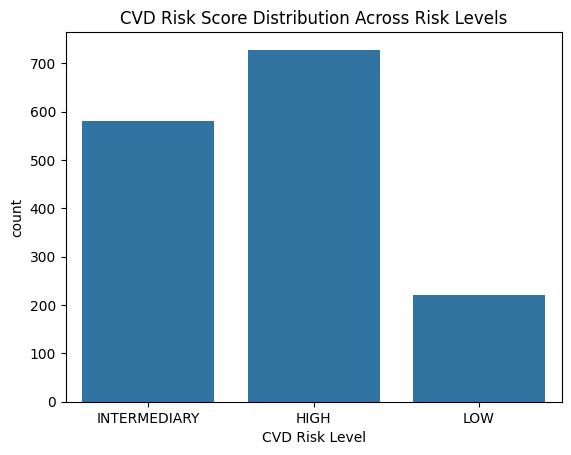

In [13]:
plt.title("CVD Risk Score Distribution Across Risk Levels")
sns.countplot(x="CVD Risk Level", data=df)

In [14]:
df["CVD Risk Level"].value_counts()

CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64

#### Summarized Findings

#### 5.3 Demographic Analysis

In this section, demographic variables such as age and sex are analyzed to examine how the population is distributed and to identify any patterns or differences across groups.

Text(0, 0.5, 'Count')

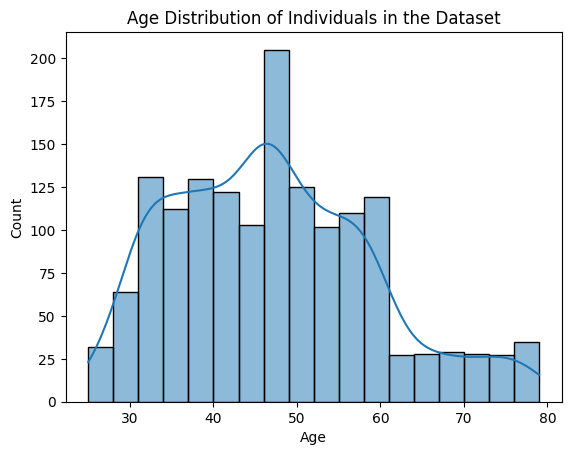

In [15]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution of Individuals in the Dataset")
plt.xlabel("Age")
plt.ylabel("Count")

The histogram shows that most individuals in the dataset are concentrated in the middle-age range (approximately 35–60 years old), with fewer individuals in the younger and older age groups.

<Axes: xlabel='CVD Risk Level', ylabel='Age'>

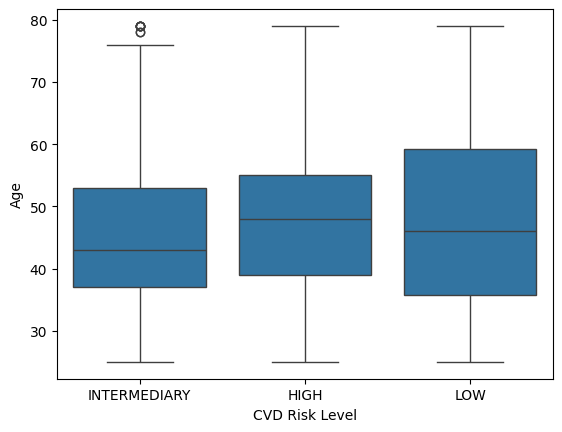

In [16]:
sns.boxplot(x="CVD Risk Level", y="Age", data=df)

The graph shows that individuals in the High CVD Risk group tend to have a slightly higher median age compared to the Intermediary and Low risk groups, suggesting that increasing age may be associated with greater cardiovascular risk.

In [17]:
df["Sex"].value_counts()

Sex
F    773
M    756
Name: count, dtype: int64

There are more females than males in the dataset

<Axes: title={'center': 'Gender Distribution Across CVD Risk Levels'}, xlabel='Sex', ylabel='count'>

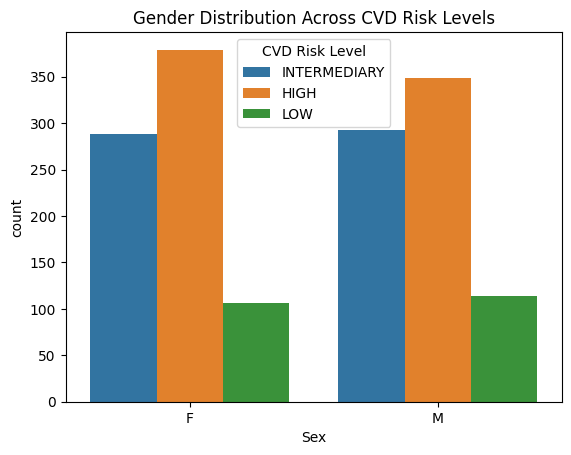

In [18]:
plt.title("Gender Distribution Across CVD Risk Levels")
sns.countplot(x="Sex", hue="CVD Risk Level", data=df)

The graph shows that females are slightly more represented than males in the dataset, which explains the higher counts observed across most CVD risk levels rather than indicating a clear gender-based difference in cardiovascular risk.

#### Summarized Findings

#### 5.4 Categorial Distributions

In this section, categorical variables are examined through frequency distributions and count plots to understand the composition of the dataset and identify general patterns across key lifestyle and health-related factors.

Sex
F    773
M    756
Name: count, dtype: int64
---
Smoking Status
Y    789
N    740
Name: count, dtype: int64
---
Diabetes Status
Y    777
N    752
Name: count, dtype: int64
---
Physical Activity Level
High        521
Moderate    512
Low         496
Name: count, dtype: int64
---
Blood Pressure Category
Hypertension Stage 2    632
Hypertension Stage 1    497
Normal                  300
Elevated                100
Name: count, dtype: int64
---
Family History of CVD
N    780
Y    749
Name: count, dtype: int64
---


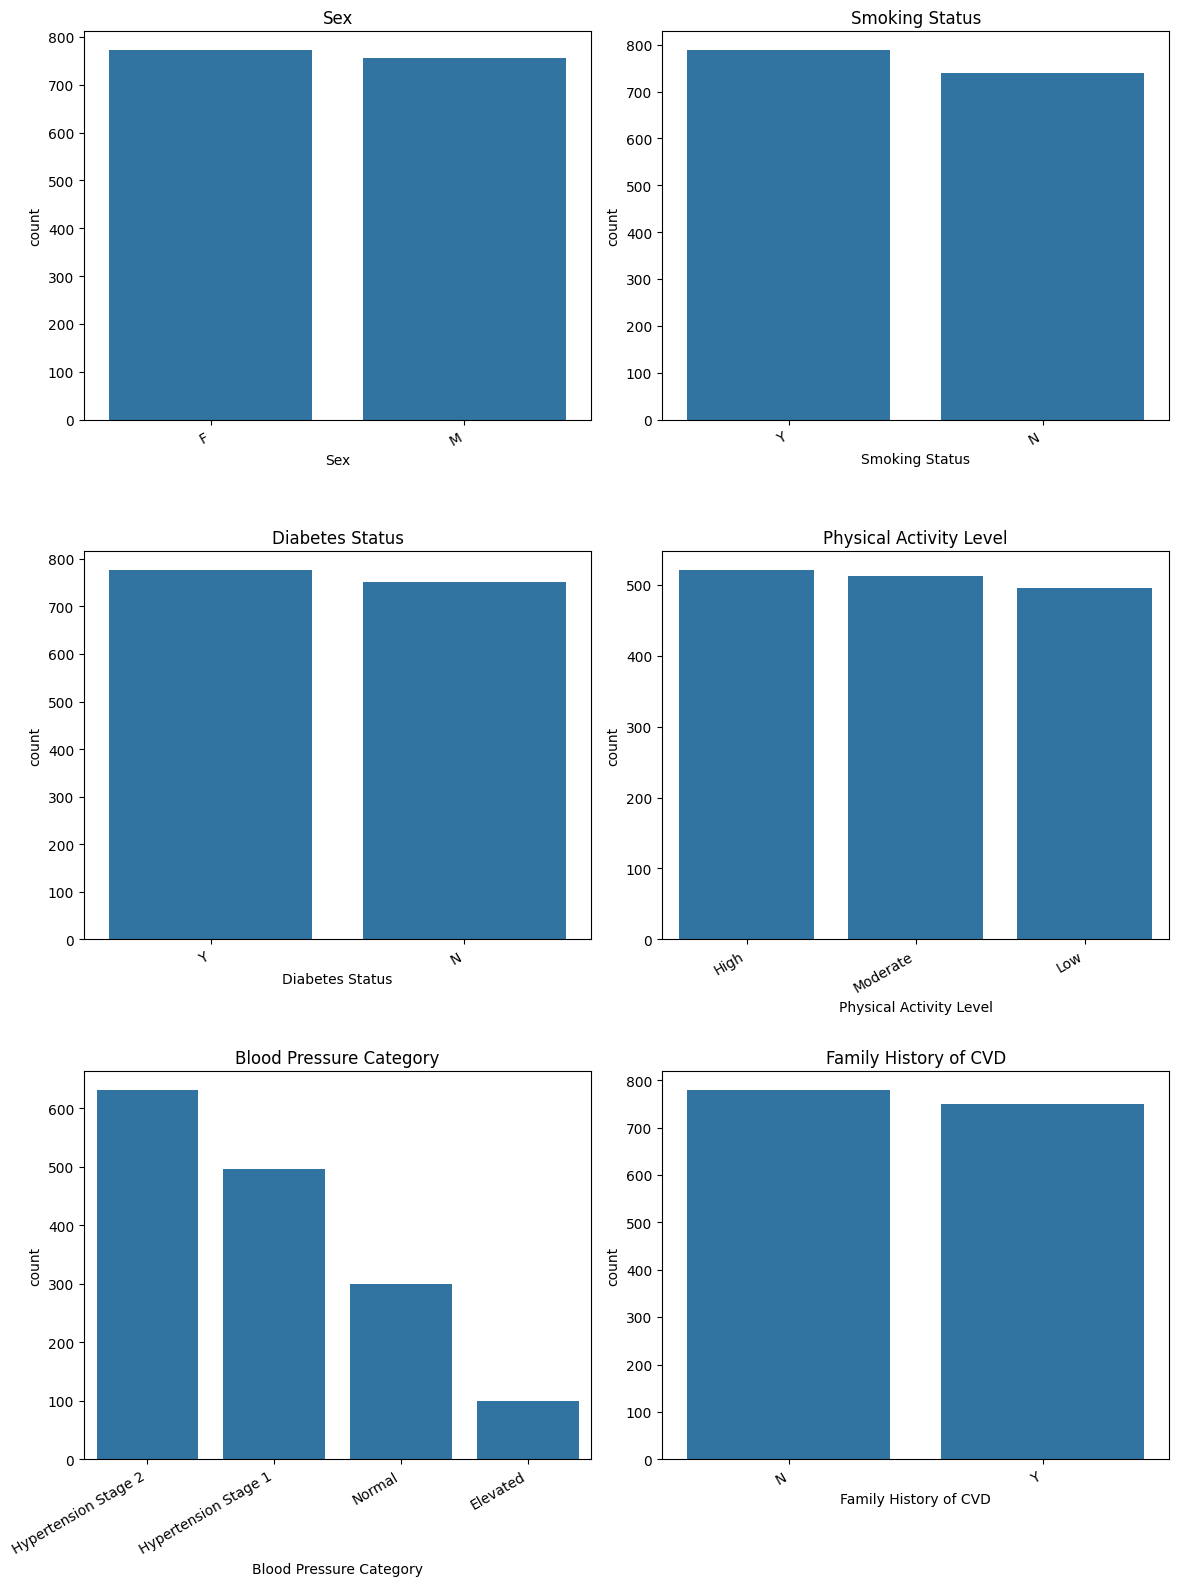

In [19]:
cat_plot_cols = ['Sex','Smoking Status','Diabetes Status','Physical Activity Level','Blood Pressure Category','Family History of CVD']
cat_plot_cols_present = [c for c in cat_plot_cols if c in df.columns]

for col_name in cat_plot_cols_present:
    print(df[col_name].value_counts(dropna=False))
    print('---')

plt.figure(figsize=(12, 20))
for idx, col_name in enumerate(cat_plot_cols_present, start=1):
    plt.subplot(4, 2, idx)
    order_vals = df[col_name].value_counts().index.tolist()
    sns.countplot(data=df, x=col_name, order=order_vals)
    plt.title(col_name)
    plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### Summarized Findings

#### 5.5 Body Measurement Analysis

In this section, body measurement variables are explored to understand their distributions and identify patterns or variations in physical characteristics within the dataset.

Text(0, 0.5, 'Count')

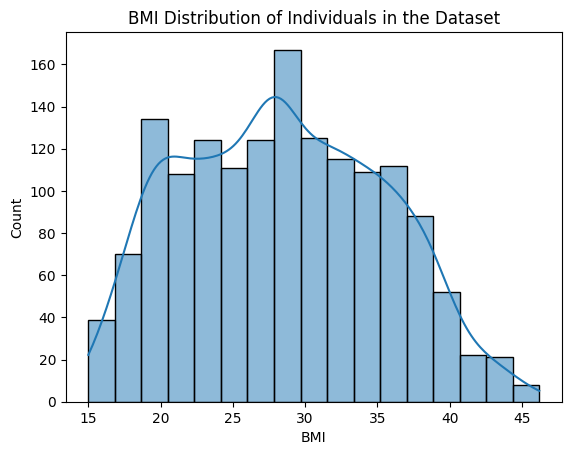

In [20]:
sns.histplot(df["BMI"], kde=True)
plt.title("BMI Distribution of Individuals in the Dataset")
plt.xlabel("BMI")
plt.ylabel("Count")

The BMI distribution is centered around the overweight range (approximately 25–30) with a slight right skew, indicating a higher concentration of individuals with elevated BMI values.

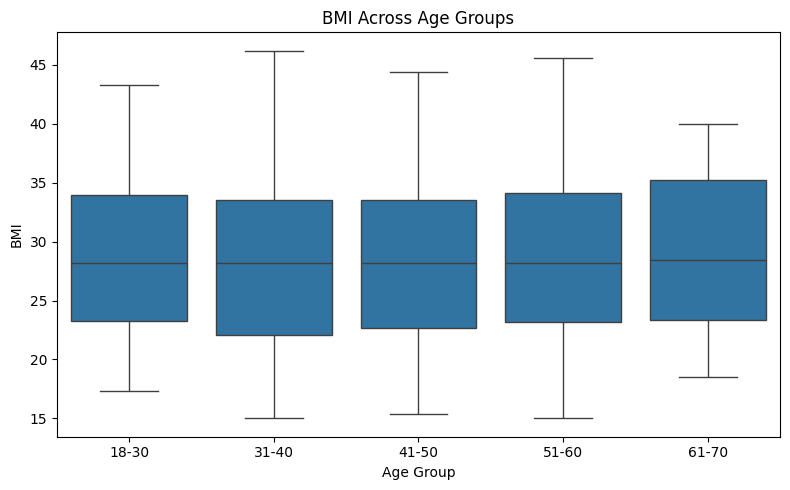

In [21]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 70],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Age Group",
    y="BMI",
    data=df
)

plt.title("BMI Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("BMI")
plt.tight_layout()
plt.show()

BMI shows a slight upward shift in median and upper range with age, with older groups (51–70) having marginally higher and more spread-out BMI compared to younger groups (18–40).

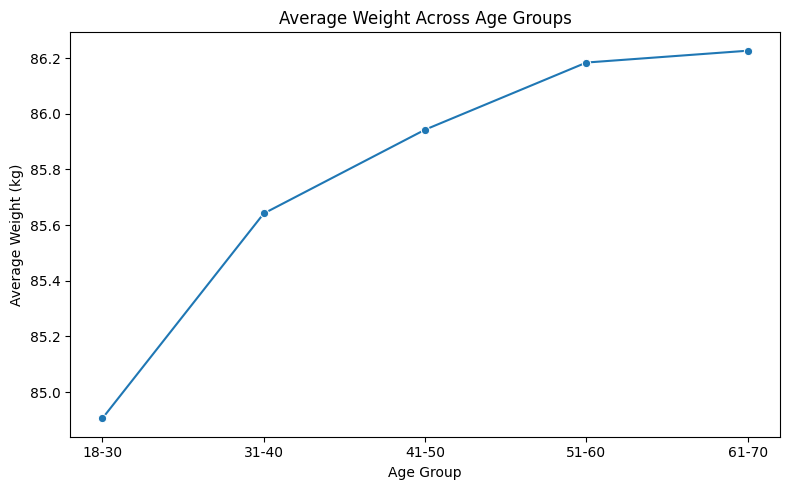

In [22]:
weight_trend = df.groupby("Age Group")["Weight (kg)"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    x="Age Group",
    y="Weight (kg)",
    data=weight_trend,
    marker="o"
)

plt.title("Average Weight Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Average Weight (kg)")
plt.tight_layout()
plt.show()

Average weight shows a slight increasing trend with age, gradually rising from younger to older age groups.

Text(0.5, 1.0, 'BMI Across CVD Risk Levels')

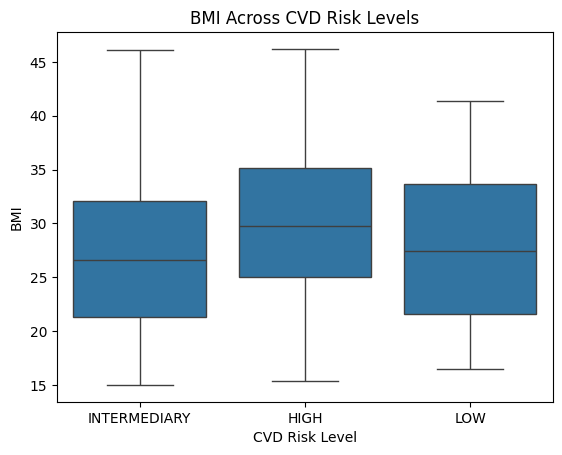

In [23]:
sns.boxplot(x="CVD Risk Level", y="BMI", data=df)
plt.title("BMI Across CVD Risk Levels")

BMI is generally higher in the high CVD risk group, but there is significant overlap across all risk levels.

Text(0.5, 1.0, 'BMI vs Waist-to-Height Ratio by CVD Risk Level')

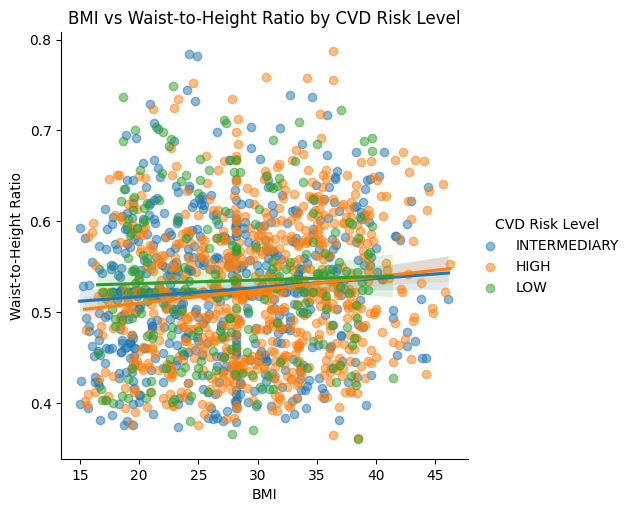

In [24]:
sns.lmplot(
    x="BMI",
    y="Waist-to-Height Ratio",
    hue="CVD Risk Level",
    data=df,
    scatter_kws={"alpha":0.5}
)
plt.title("BMI vs Waist-to-Height Ratio by CVD Risk Level")

Text(0.5, 1.0, 'Waist-to-Height Ratio Across CVD Risk Levels')

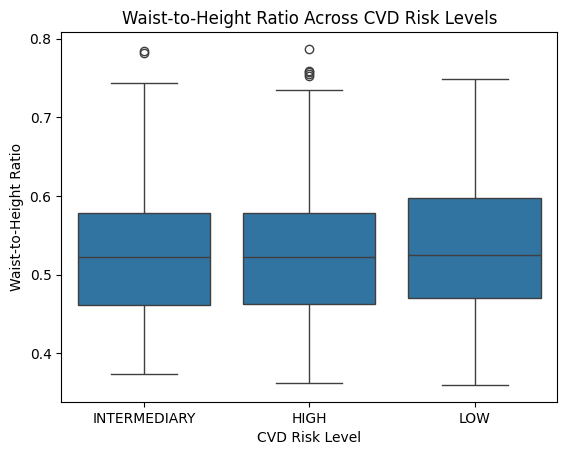

In [25]:
sns.boxplot(x="CVD Risk Level", y="Waist-to-Height Ratio", data=df)
plt.title("Waist-to-Height Ratio Across CVD Risk Levels")

Waist-to-height ratio is very similar across all CVD risk levels, with only a slight increase in the HIGH group, but overall differences are minimal and heavily overlapping.

#### Summarized Findings

#### 5.6 Lifestyle and Health Factors

In this section, lifestyle and health-related factors are analyzed to examine how behaviors and conditions vary across different groups and potentially relate to overall health outcomes.

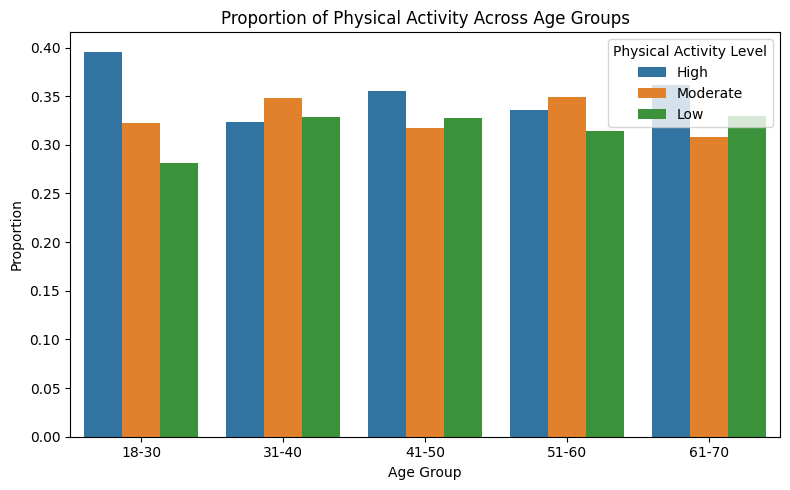

In [26]:
activity_prop = (
    df.groupby("Age Group")["Physical Activity Level"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Age Group",
    y="Proportion",
    hue="Physical Activity Level",
    data=activity_prop
)

plt.title("Proportion of Physical Activity Across Age Groups")
plt.tight_layout()
plt.show()

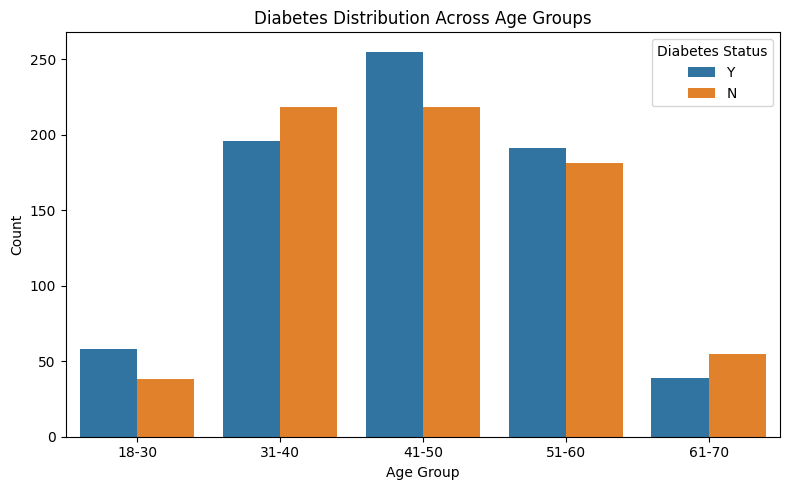

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Age Group",
    hue="Diabetes Status", 
    data=df
)

plt.title("Diabetes Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Proportion')

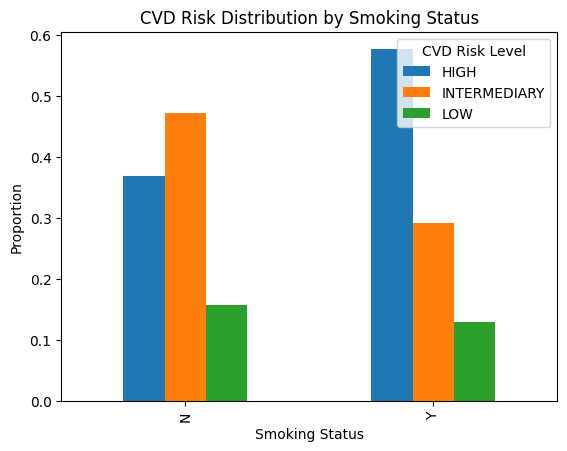

In [28]:
smoking_risk = pd.crosstab(df["Smoking Status"], df["CVD Risk Level"], normalize="index")

smoking_risk.plot(kind="bar", stacked=False)
plt.title("CVD Risk Distribution by Smoking Status")
plt.ylabel("Proportion")

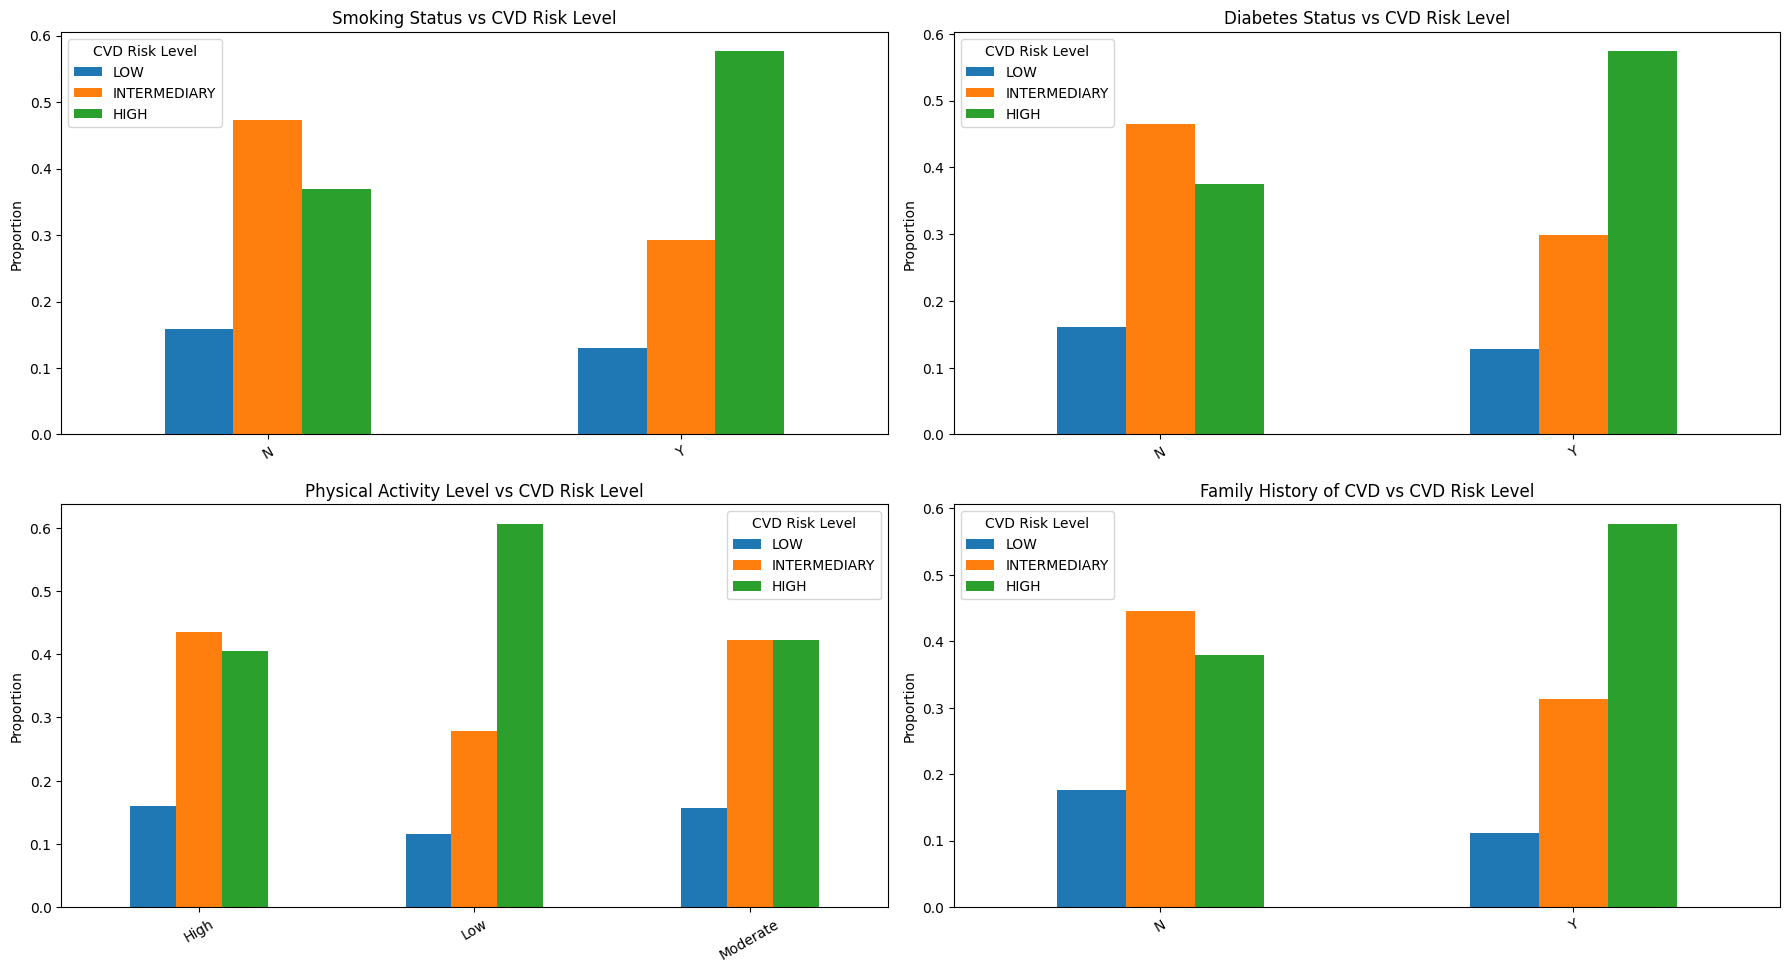


Smoking Status
CVD Risk Level   HIGH  INTERMEDIARY    LOW
Smoking Status                            
N               0.369         0.473  0.158
Y               0.577         0.293  0.131

Diabetes Status
CVD Risk Level    HIGH  INTERMEDIARY    LOW
Diabetes Status                            
N                0.375         0.464  0.161
Y                0.574         0.299  0.127

Physical Activity Level
CVD Risk Level            HIGH  INTERMEDIARY    LOW
Physical Activity Level                            
High                     0.405         0.436  0.159
Low                      0.607         0.278  0.115
Moderate                 0.422         0.422  0.156

Family History of CVD
CVD Risk Level          HIGH  INTERMEDIARY    LOW
Family History of CVD                            
N                      0.379         0.445  0.176
Y                      0.577         0.312  0.111


In [29]:
risk_order = ['LOW', 'INTERMEDIARY', 'HIGH']

cat_vars = [
    'Smoking Status',
    'Diabetes Status',
    'Physical Activity Level',
    'Family History of CVD'
]

cat_vars_present = [col for col in cat_vars if col in df.columns]

plt.figure(figsize=(18, 14))

for i, col in enumerate(cat_vars_present, 1):
    plt.subplot(3, 2, i)
    
    ctab = pd.crosstab(df[col], df['CVD Risk Level'], normalize='index')
    ctab = ctab.reindex(columns=risk_order)
    
    ctab.plot(kind='bar', stacked=False, ax=plt.gca())
    
    plt.title(f'{col} vs CVD Risk Level')
    plt.xlabel('')
    plt.ylabel('Proportion')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

for col in cat_vars_present:
    print(f"\n{col}")
    print(pd.crosstab(df[col], df['CVD Risk Level'], normalize='index').round(3))

#### Summarized Findings

#### 5.7 Clinical indicators

#### Blood Pressure

In this section, clinical indicators are analyzed to assess their distributions and observe how they vary across different CVD risk levels.

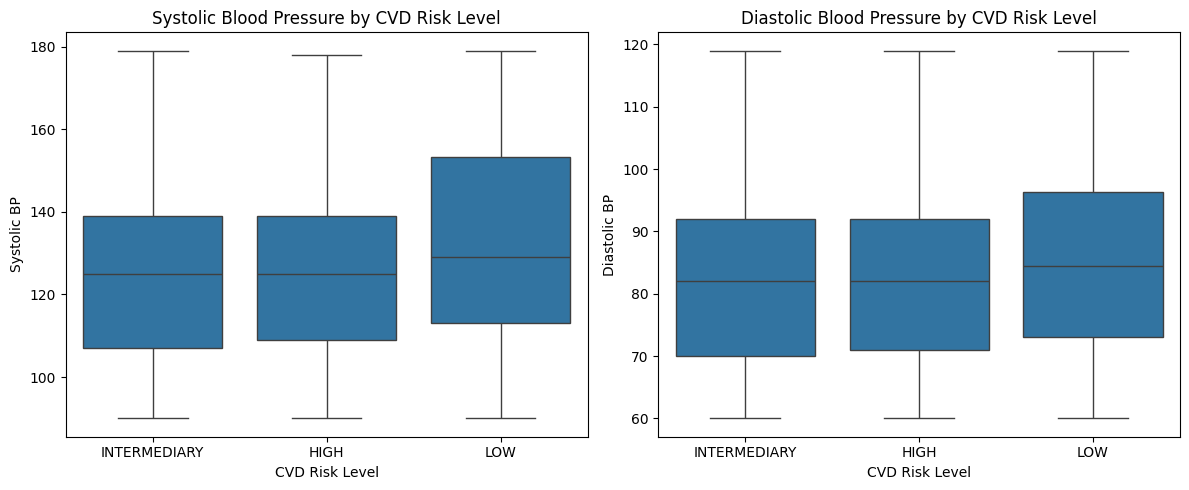

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Systolic BP
sns.boxplot(
    x="CVD Risk Level",
    y="Systolic BP",
    data=df,
    ax=axes[0]
)
axes[0].set_title("Systolic Blood Pressure by CVD Risk Level")

# Diastolic BP
sns.boxplot(
    x="CVD Risk Level",
    y="Diastolic BP",
    data=df,
    ax=axes[1]
)
axes[1].set_title("Diastolic Blood Pressure by CVD Risk Level")

plt.tight_layout()
plt.show()

Both systolic and diastolic blood pressure show a slight increase in median and variability in higher CVD risk groups, but with considerable overlap across all levels.

#### Cholesterol Profile

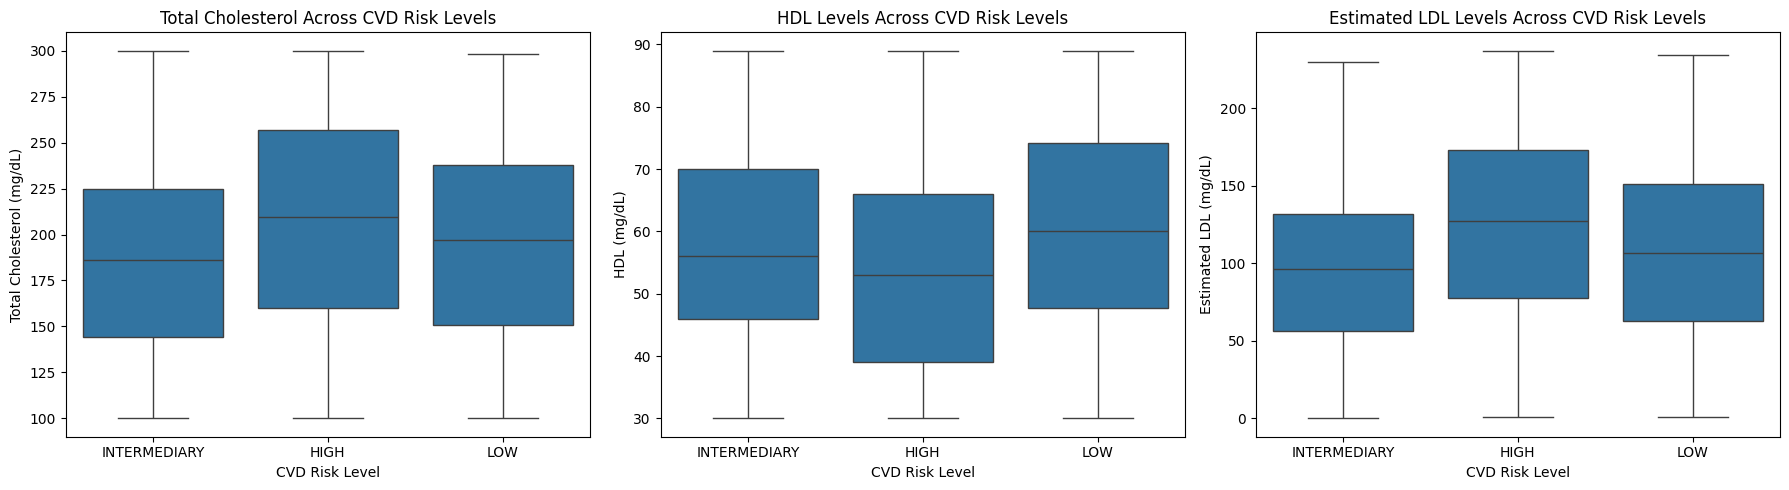

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(x="CVD Risk Level", y="Total Cholesterol (mg/dL)", data=df, ax=axes[0])
axes[0].set_title("Total Cholesterol Across CVD Risk Levels")

sns.boxplot(x="CVD Risk Level", y="HDL (mg/dL)", data=df, ax=axes[1])
axes[1].set_title("HDL Levels Across CVD Risk Levels")

sns.boxplot(x="CVD Risk Level", y="Estimated LDL (mg/dL)", data=df, ax=axes[2])
axes[2].set_title("Estimated LDL Levels Across CVD Risk Levels")

plt.tight_layout()
plt.show()

Higher CVD risk is generally associated with increased total cholesterol and LDL and slightly lower HDL, although substantial overlap between groups indicates these markers alone do not fully distinguish risk levels.


#### Blood Sugar

Text(0, 0.5, 'Fasting Blood Sugar (mg/dL)')

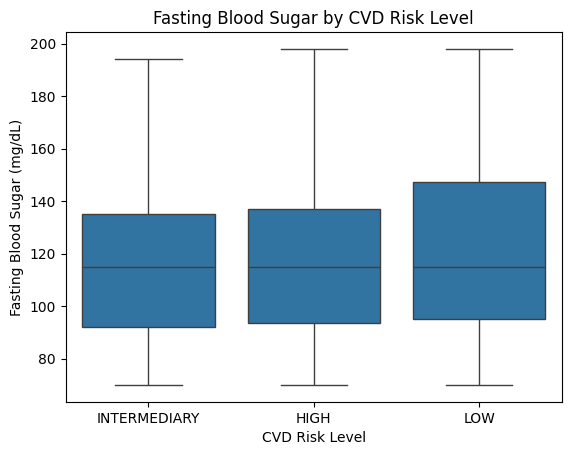

In [32]:
sns.boxplot(
    x="CVD Risk Level",
    y="Fasting Blood Sugar (mg/dL)",
    data=df
)

plt.title("Fasting Blood Sugar by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Fasting Blood Sugar (mg/dL)")

Fasting blood sugar levels are fairly similar across all CVD risk groups, with only slight increases in variability at higher risk levels

#### Summarized Findings

#### 5.8 Correlation Heatmap of Numerical Features

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

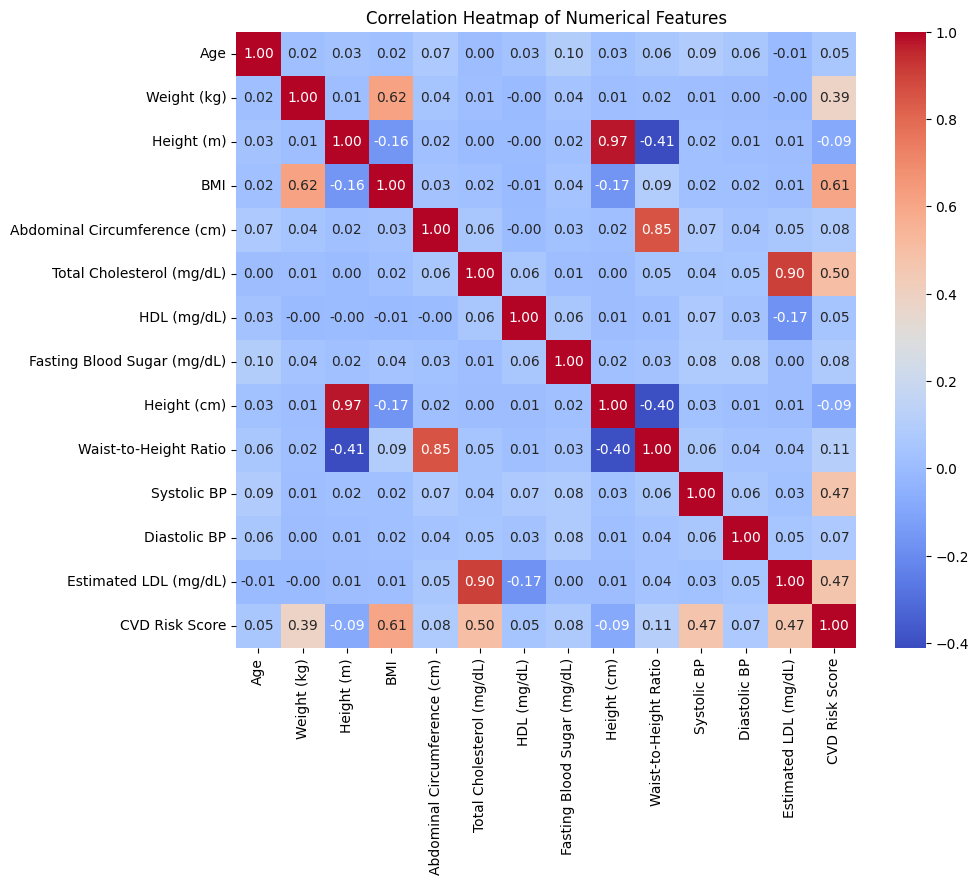

In [33]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

#### Summarized Findings

#### 5.9 EDA Conclusions

* **Note:** Age Group was engineered solely for EDA visualization and was removed before modeling since it is derived from Age and introduces redundancy.

In [34]:
df = df.drop(columns=['Age Group'])

# Section 6. Model Training

#### 6.1 Feature Selection

In [35]:
numerical_features = [
    'Age',
    'BMI',
    'Height (cm)',
    'Abdominal Circumference (cm)',
    'Waist-to-Height Ratio',
    'Systolic BP',
    'Diastolic BP',
    'Total Cholesterol (mg/dL)',
    'HDL (mg/dL)',
    'Estimated LDL (mg/dL)',
    'Fasting Blood Sugar (mg/dL)',
]
categorical_features = [
    'Sex',
    'Smoking Status',
    'Diabetes Status',
    'Physical Activity Level',
    'Family History of CVD'
]
target = 'CVD Risk Level'

#### ANOVA Test for Numerical Features

In [36]:
anova_results = []

for feature in numerical_features:
    low = df[df[target] == 'LOW'][feature].dropna()
    medium = df[df[target] == 'INTERMEDIARY'][feature].dropna()
    high = df[df[target] == 'HIGH'][feature].dropna()
    
    f_stat, p_value = f_oneway(low, medium, high)
    
    anova_results.append({
        'Feature': feature,
        'Test': 'ANOVA',
        'Statistic': round(f_stat, 4),
        'p-value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results)
anova_df

,Feature,Test,Statistic,p-value,Significant
0,Age,ANOVA,5.6595,0.003558,Yes
1,BMI,ANOVA,28.0091,0.000000,Yes
2,Height (cm),ANOVA,2.0385,0.130576,No
3,Abdominal Circumference (cm),ANOVA,1.7646,0.171597,No
4,Waist-to-Height Ratio,ANOVA,1.6391,0.194487,No
5,Systolic BP,ANOVA,12.1010,0.000006,Yes
6,Diastolic BP,ANOVA,6.5150,0.001523,Yes
7,Total Cholesterol (mg/dL),ANOVA,22.0504,0.000000,Yes
8,HDL (mg/dL),ANOVA,24.3644,0.000000,Yes
9,Estimated LDL (mg/dL),ANOVA,35.7582,0.000000,Yes


#### Chi-Square Test for Categorical Features

In [37]:
chi_results = []

for feature in categorical_features:
    table = pd.crosstab(df[feature], df[target])
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    chi_results.append({
        'Feature': feature,
        'Test': 'Chi-square',
        'Statistic': round(chi2, 4),
        'p-value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_results)
chi_df

,Feature,Test,Statistic,p-value,Significant
0,Sex,Chi-square,1.3814,0.501235,No
1,Smoking Status,Chi-square,69.2652,0.000000,Yes
2,Diabetes Status,Chi-square,62.3141,0.000000,Yes
3,Physical Activity Level,Chi-square,50.9401,0.000000,Yes
4,Family History of CVD,Chi-square,60.0349,0.000000,Yes


Feature testing using ANOVA (for numerical variables) and Chi-square (for categorical variables) was performed to identify which features are significantly associated with CVD Risk Level. This ensures that only relevant variables are used for model training.

#### Dropping of features

In [38]:
df = df.drop(columns=["Sex", "Height (cm)", "Blood Pressure (mmHg)", "Abdominal Circumference (cm)", "Total Cholesterol (mg/dL)", "Waist-to-Height Ratio", "Height (m)", "Blood Pressure Category", "CVD Risk Score"])

In [39]:
print("Remaining columns after dropping:")
for col in df.columns:
    if col not in ['CVD Risk Level']:
        print("Feature:", col)

print("\nLabel:", 'CVD Risk Level')

Remaining columns after dropping:
Feature: Age
Feature: Weight (kg)
Feature: BMI
Feature: HDL (mg/dL)
Feature: Fasting Blood Sugar (mg/dL)
Feature: Smoking Status
Feature: Diabetes Status
Feature: Physical Activity Level
Feature: Family History of CVD
Feature: Systolic BP
Feature: Diastolic BP
Feature: Estimated LDL (mg/dL)

Label: CVD Risk Level


The features **Blood Pressure Category** and **CVD Risk Score** were removed from the dataset 
before model training. These variables are directly related to the target variable 
**CVD Risk Level**, which the model is intended to predict.

Including **CVD Risk Score** would allow the model to effectively *cheat*, since the 
risk level is derived from this score. The model could simply learn rules 
such as *if risk score > 15 → High risk* instead of learning the underlying relationships 
between the health indicators (e.g., blood pressure, cholesterol, BMI) and cardiovascular risk.

Furthermore, Total Cholesterol was removed due to its high correlation with Estimated LDL (r ≈ 0.90) and its nature as an aggregate lipid measure. Instead of using a combined indicator, the model retains individual lipid components (e.g., LDL and HDL), allowing it to learn more granular and clinically meaningful relationships. This is also to avoid redundancy in our dataset

Additionally, the feature Blood Pressure (mmHg) was excluded due to redundancy. This variable represents a combined measurement of systolic and diastolic pressure (e.g., “120/80”), which are already included as separate numerical features (Systolic BP and Diastolic BP)

To ensure that the model learns meaningful physiological patterns rather than relying on 
derived labels, these variables were excluded from the feature set.

#### 6.2 Feature Encoding

Ordinal Mapping

In [40]:
binary_cols = ['Smoking Status', 'Diabetes Status', 'Family History of CVD']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Y': 1, 'N': 0})

In [41]:
df = pd.get_dummies(df, columns=["Physical Activity Level"], drop_first=True)

#### 6.3 Train/Test/Validation Split

The dataset was split into training, test, and validation sets using a **70:15:15 ratio**, respectively.

In [42]:
X = df.drop(['CVD Risk Level'], axis=1, errors='ignore')
y = df['CVD Risk Level']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1529, 13)
Shape of y: (1529,)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [44]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=1, stratify=y_test)

In [45]:
print("Training set shape (X,y):", X_train.shape, y_train.shape)
print("Test set shape (X,y):", X_test.shape, y_test.shape)
print("Validation set shape (X,y):", X_val.shape, y_val.shape)

Training set shape (X,y): (1070, 13) (1070,)
Test set shape (X,y): (229, 13) (229,)
Validation set shape (X,y): (230, 13) (230,)


#### 6.4 Scaling

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#### 6.5.1 KNN

In [47]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_scaled, y_train)

y_predicted_val = model.predict(X_val_scaled)
print("Accuracy:", accuracy_score(y_val, y_predicted_val))
print(classification_report(y_val, y_predicted_val))

Accuracy: 0.6086956521739131
              precision    recall  f1-score   support

        HIGH       0.65      0.72      0.68       110
INTERMEDIARY       0.57      0.61      0.59        87
         LOW       0.53      0.24      0.33        33

    accuracy                           0.61       230
   macro avg       0.58      0.52      0.53       230
weighted avg       0.60      0.61      0.60       230



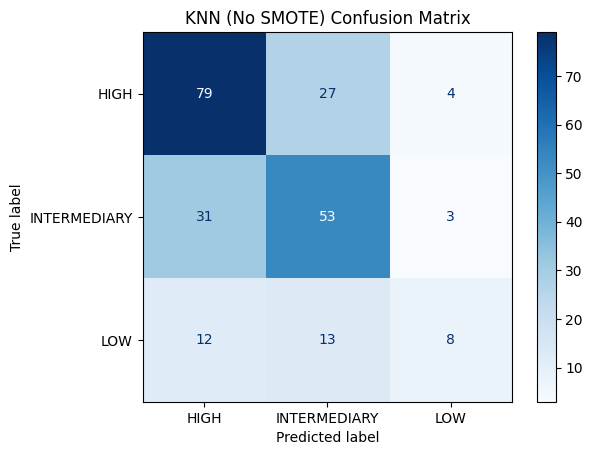

In [48]:
cm = confusion_matrix(y_val, y_predicted_val)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['HIGH', 'INTERMEDIARY', 'LOW']
)

disp.plot(cmap='Blues')
plt.title("KNN (No SMOTE) Confusion Matrix")
plt.show()

#### 6.5.2 Logistic Regression

In [49]:
model = SGDClassifier(
    loss='log_loss',
    alpha=0.0001,
    max_iter=2000,
    tol=1e-4,
    class_weight='balanced',
    random_state=42
)

In [50]:
model.fit(X_train_scaled, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",2000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.0001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [51]:
y_predicted_val = model.predict(X_val_scaled)

print("Accuracy:", accuracy_score(y_val, y_predicted_val))
print("\nClassification Report:")
print(classification_report(y_val, y_predicted_val))

Accuracy: 0.5521739130434783

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.69      0.69      0.69       110
INTERMEDIARY       0.53      0.53      0.53        87
         LOW       0.15      0.15      0.15        33

    accuracy                           0.55       230
   macro avg       0.46      0.46      0.46       230
weighted avg       0.55      0.55      0.55       230



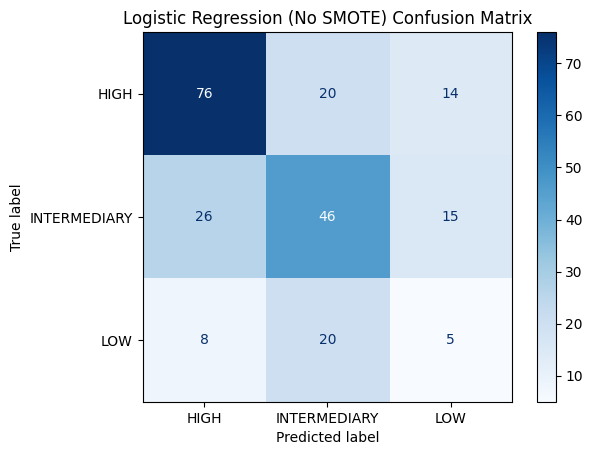

In [52]:
cm = confusion_matrix(y_val, y_predicted_val)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['HIGH', 'INTERMEDIARY', 'LOW']
)

disp.plot(cmap='Blues')
plt.title("Logistic Regression (No SMOTE) Confusion Matrix")
plt.show()

#### 6.6 Addressing Class Imbalance

In [53]:
print(pd.Series(y_train).value_counts())

CVD Risk Level
HIGH            509
INTERMEDIARY    407
LOW             154
Name: count, dtype: int64


In [54]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [55]:
print(pd.Series(y_train_res).value_counts())

CVD Risk Level
INTERMEDIARY    509
HIGH            509
LOW             509
Name: count, dtype: int64


#### 6.6.1 KNN

In [56]:
model = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

In [57]:
model.fit(X_train_res, y_train_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [58]:
y_predicted_val = model.predict(X_val_scaled)

In [59]:
print("Accuracy:", accuracy_score(y_val, y_predicted_val))
print(classification_report(y_val, y_predicted_val))

Accuracy: 0.6130434782608696
              precision    recall  f1-score   support

        HIGH       0.73      0.61      0.66       110
INTERMEDIARY       0.60      0.60      0.60        87
         LOW       0.42      0.67      0.52        33

    accuracy                           0.61       230
   macro avg       0.59      0.62      0.59       230
weighted avg       0.64      0.61      0.62       230



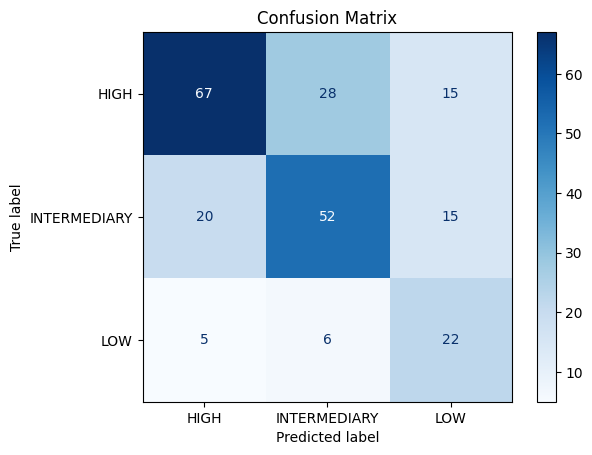

In [60]:

cm = confusion_matrix(y_val, y_predicted_val)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['HIGH', 'INTERMEDIARY', 'LOW']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### 6.6.2 Logistic Regression

In [61]:
model = SGDClassifier(
    loss='log_loss',
    alpha=0.0001,      
    max_iter=2000,
    tol=1e-4,
    class_weight='balanced',
    random_state=42
)

In [62]:
model.fit(X_train_res, y_train_res)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",2000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.0001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [63]:
y_predicted_val = model.predict(X_val_scaled)

In [64]:
print(f'Accuracy Score: {accuracy_score(y_val, y_predicted_val)}')
print('\nClassification Report:')
print(classification_report(y_val, y_predicted_val, target_names=['HIGH', 'INTERMEDIARY', 'LOW'], digits=4))

Accuracy Score: 0.5304347826086957

Classification Report:
              precision    recall  f1-score   support

        HIGH     0.6754    0.7000    0.6875       110
INTERMEDIARY     0.5312    0.3908    0.4503        87
         LOW     0.2115    0.3333    0.2588        33

    accuracy                         0.5304       230
   macro avg     0.4727    0.4747    0.4656       230
weighted avg     0.5543    0.5304    0.5363       230



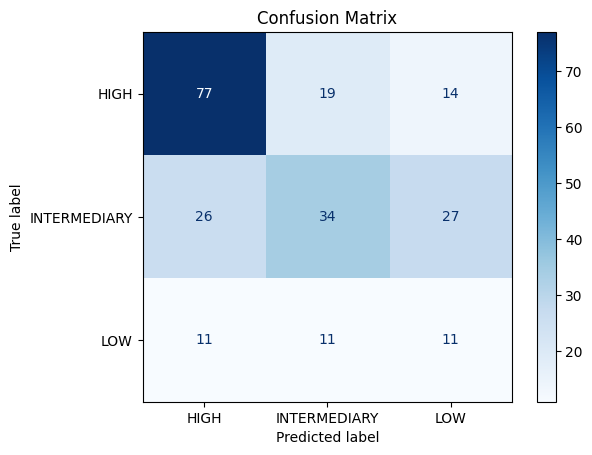

In [65]:

cm = confusion_matrix(y_val, y_predicted_val)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['HIGH', 'INTERMEDIARY', 'LOW']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### 6.7 Binary Classification

In [66]:
df['CVD_Risk_Binary'] = df['CVD Risk Level'].apply(
    lambda x: 'HIGH' if x == 'HIGH' else 'NOT HIGH'
)

In [67]:
X = df.drop(columns=[
    'CVD Risk Level',     # original label
    'CVD_Risk_Binary'   # new label
], errors='ignore')

y = df['CVD_Risk_Binary']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1529, 13)
Shape of y: (1529,)


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [69]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=1, stratify=y_test)

In [70]:
print("Training set shape (X,y):", X_train.shape, y_train.shape)
print("Test set shape (X,y):", X_test.shape, y_test.shape)
print("Validation set shape (X,y):", X_val.shape, y_val.shape)

Training set shape (X,y): (1070, 13) (1070,)
Test set shape (X,y): (229, 13) (229,)
Validation set shape (X,y): (230, 13) (230,)


In [71]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [72]:
print(pd.Series(y_train).value_counts())

CVD_Risk_Binary
NOT HIGH    561
HIGH        509
Name: count, dtype: int64


In [73]:

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [74]:
print(pd.Series(y_train_res).value_counts())

CVD_Risk_Binary
HIGH        561
NOT HIGH    561
Name: count, dtype: int64


#### 6.7.1 KNN

In [75]:
model = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

In [76]:
model.fit(X_train_res, y_train_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [77]:
y_predicted_val = model.predict(X_val_scaled)

In [78]:
print("Accuracy:", accuracy_score(y_val, y_predicted_val))
print(classification_report(y_val, y_predicted_val))

Accuracy: 0.6695652173913044
              precision    recall  f1-score   support

        HIGH       0.66      0.65      0.65       110
    NOT HIGH       0.68      0.69      0.69       120

    accuracy                           0.67       230
   macro avg       0.67      0.67      0.67       230
weighted avg       0.67      0.67      0.67       230



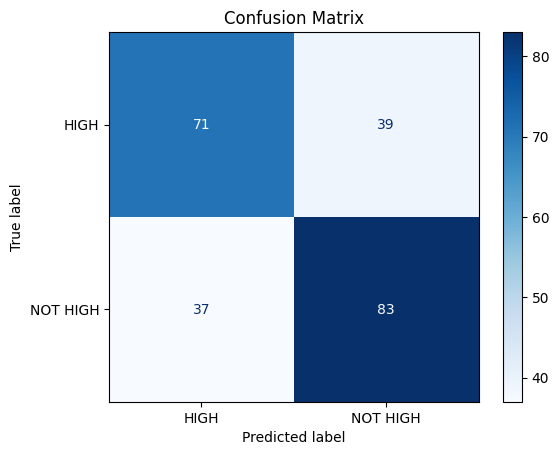

In [79]:
cm = confusion_matrix(y_val, y_predicted_val)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['HIGH', 'NOT HIGH']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### 6.7.2 Logistic Regression

In [80]:
model = SGDClassifier(
    loss='log_loss',
    alpha=0.0001,      
    max_iter=2000,
    tol=1e-4,
    class_weight='balanced',
    random_state=42
)

In [81]:
model.fit(X_train_res, y_train_res)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",2000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.0001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [82]:
y_predicted_val = model.predict(X_val_scaled)

In [83]:
print("Accuracy:", accuracy_score(y_val, y_predicted_val))
print(classification_report(y_val, y_predicted_val))

Accuracy: 0.6652173913043479
              precision    recall  f1-score   support

        HIGH       0.66      0.63      0.64       110
    NOT HIGH       0.67      0.70      0.69       120

    accuracy                           0.67       230
   macro avg       0.66      0.66      0.66       230
weighted avg       0.66      0.67      0.66       230



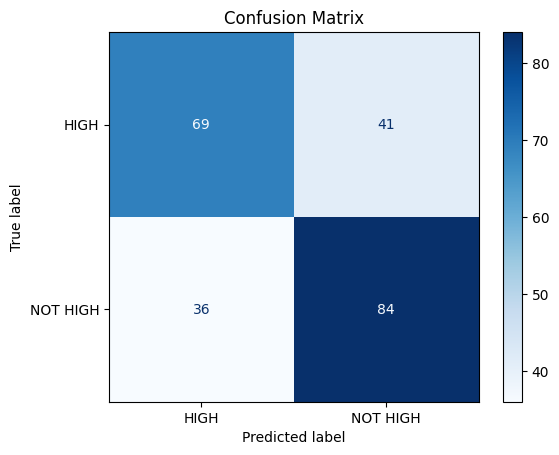

In [84]:
cm = confusion_matrix(y_val, y_predicted_val)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['HIGH', 'NOT HIGH']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Neural Network

Despite the resuls of previous models, the neural network may be more fitting for this prediction task as the dataset contains many instances and features. The neural network may be more accurate as it should be able to understand the complex, non-linear correlations between features.

In [113]:
import torch.optim as optim
import torch.nn as nn
from skorch import NeuralNetClassifier
from neural_network import CVDModel
import torch

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

Before training, the dataset is cleared of the label column, and the targets ('LOW', 'INTERMEDIARY', 'HIGH') are first made into integer values. After this the dataset is split.

Numerical features are standardized using the StandardScaler to ensure that features with larger ranges do not disproportionately influence the model's weight updates during training.

In [114]:
X = df.drop(columns=['CVD Risk Level', 'CVD_Risk_Binary'], errors='ignore')

le = LabelEncoder()
y = le.fit_transform(df['CVD Risk Level'])

Training Set: 70%
Validation Set: 15%
Test Set: 15%

In [115]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1, stratify=y_temp)

Before we proceed to configuring the neural network, the data must first be preprocessed and standardized, especially given the various data types in the dataset.

In [116]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Features: {X_train_scaled.shape[1]}")
print(f"Target classes: {le.classes_}")

Features: 13
Target classes: ['HIGH' 'INTERMEDIARY' 'LOW']


Initialize the neural network model.

In [120]:
input_dim = X_train_scaled.shape[1] 
hidden_dims = [36, 18]               # idk what to put here
dropout_val = 0.2

# Initialize Model
model = NeuralNetClassifier(
    module=CVDModel,
    module__input_size=input_dim,
    module__list_hidden=hidden_dims,
    module__activation='relu', # we can try dif activation funcs here
    module__dropout=dropout_val,
    criterion=nn.CrossEntropyLoss,
    optimizer=optim.Adam,
    lr=0.001,
    max_epochs=100,
    batch_size=32,
)

print(model)

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class 'neural_network.CVDModel'>,
  module__activation=relu,
  module__dropout=0.2,
  module__input_size=13,
  module__list_hidden=[36, 18],
)


Fit the model.

In [121]:
X_train_nn = X_train_scaled.astype(np.float32)
y_train_nn = y_train.astype(np.int64)
model.fit(X_train_nn, y_train_nn)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.0951       0.4766        1.0241  0.1344
      2        0.9936       0.5140        1.0000  0.1315
      3        0.9718       0.5701        0.9863  0.1341
      4        0.9436       0.5748        0.9759  0.1321


      5        0.9059       0.5888        0.9651  0.1753
      6        0.9112       0.6028        0.9562  0.1720
      7        0.8954       0.6121        0.9538  0.1610
      8        0.8760       0.6215        0.9482  0.1724
      9        0.8496       0.6028        0.9411  0.1556
     10        0.8570       0.6168        0.9349  0.1450
     11        0.8278       0.6262        0.9332  0.1699
     12        0.8409       0.6355        0.9259  0.1534
     13        0.8232       0.6355        0.9242  0.1485
     14        0.8249       0.6449        0.9209  0.1385
     15        0.8084       0.6262        0.9134  0.1419
     16        0.7959       0.6075        0.9096  0.1372
     17        0.7943       0.6121        0.9098  0.1413
     18        0.7777       0.6121        0.9110  0.1444
     19        0.7984       0.6075        0.9047  0.1702
     20        0.7861       0.6028        0.9000  0.1431
     21        0.7866       0.6028        0.8954  0.1455
     22        0.7863       0.6

,module,<class 'neura...ork.CVDModel'>
,criterion,<class 'torch...sEntropyLoss'>
,train_split,<skorch.datas...00288722F3110>
,classes,None
,optimizer,<class 'torch...im.adam.Adam'>
,lr,0.001
,max_epochs,100
,batch_size,32
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>


Evaluate the current calibration of the neural netwokr.

In [119]:
from sklearn.metrics import classification_report, confusion_matrix

X_val_nn = X_val_scaled.astype(np.float32)
y_pred = model.predict(X_val_nn)
print(classification_report(y_val, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        HIGH       0.64      0.83      0.72       109
INTERMEDIARY       0.58      0.57      0.58        87
         LOW       0.00      0.00      0.00        33

    accuracy                           0.62       229
   macro avg       0.41      0.47      0.43       229
weighted avg       0.52      0.62      0.56       229



c:\Users\Sofia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sofia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sofia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Similar to the other models, the neural network can somewhat identify those with high cardiovascular risk, but poorly identifies low risk patients.

We can further try to increase accuracy in classification through hyperparamter tuning.

#### Hyperparameter Tuning